In [2]:
# importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Data Loading

In [40]:

from google.colab import files

uploaded = files.upload()

Saving store_sales.csv to store_sales.csv


In [5]:
# path ='/content/drive/MyDrive/train (1).csv'



Data Details

In [43]:
train = pd.read_csv('store_sales.csv')


In [44]:
train.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [45]:
train.shape

(7300, 5)

In [46]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   object 
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 285.3+ KB


Convert date

In [47]:
train['date'] = pd.to_datetime(train['date'])

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7300 non-null   datetime64[ns]
 1   store    7300 non-null   int64         
 2   sales    7300 non-null   float64       
 3   promo    7300 non-null   int64         
 4   holiday  7300 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 285.3 KB


Checking for date range

In [48]:
print("Start date:", train['date'].min())
print("End date:", train['date'].max())

Start date: 2022-01-01 00:00:00
End date: 2023-12-31 00:00:00


##Data Cleaning

Check duplicate rows

In [51]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


Checking Missing Values

In [52]:
print(train.isnull().sum())

date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64


Checking DataTypes

In [53]:
print(train.dtypes)

date       datetime64[ns]
store               int64
sales             float64
promo               int64
holiday             int64
dtype: object


Check for invalid sales values

In [54]:
print("Negative sales:", (train['sales'] < 0).sum())

Negative sales: 0


Checking for Unique IDs

In [58]:
print("Unique IDs:", train['date'].nunique())
print("Total rows:", len(train))

Unique IDs: 730
Total rows: 7300


Checking Actual Variables

In [59]:
print("\nPromotion values:")
print(train['promo'].value_counts())

print("\nHoliday values:")
print(train['holiday'].value_counts())


Promotion values:
promo
0    5824
1    1476
Name: count, dtype: int64

Holiday values:
holiday
0    6540
1     760
Name: count, dtype: int64


Basic data validation

In [60]:
print("Negative sales:", (train['sales'] < 0).sum())
print("Negative promotion values:", (train['promo'] < 0).sum())
print("Total rows:", len(train))

Negative sales: 0
Negative promotion values: 0
Total rows: 7300


Outlier detection/handling

In [123]:
Q1 = train_df['sales'].quantile(0.25)
Q3 = train_df['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[
    (train_df['sales'] < lower_bound) |
    (train_df['sales'] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers) / len(train_df) * 100, 2), "%")

Lower bound: 154.17375000000004
Upper bound: 291.50374999999997
Number of outliers: 54
Percentage of outliers: 1.1 %


Copy of clean data

In [61]:
clean_train = train.copy()

Saving clean dataset in drive for record

In [63]:
import os

save_path = '/content/drive/MyDrive/'
os.makedirs(save_path, exist_ok=True)

clean_train.to_csv(
    f'{save_path}/clean_train.csv',
    index=False
)

print("Clean dataset saved successfully!")
print(f"Location: {save_path}/clean_train.csv")

Clean dataset saved successfully!
Location: /content/drive/MyDrive//clean_train.csv


Create the date features

In [64]:
clean_train = train.copy()

clean_train['year'] = clean_train['date'].dt.year
clean_train['month'] = clean_train['date'].dt.month
clean_train['day'] = clean_train['date'].dt.day
clean_train['day_of_week'] = clean_train['date'].dt.dayofweek
clean_train['is_weekend'] = clean_train['day_of_week'].isin([5, 6]).astype(int)

clean_train.head()

,date,store,sales,promo,holiday,year,month,day,day_of_week,is_weekend
0,2022-01-01,1,184.78,0,0,2022,1,1,5,1
1,2022-01-02,1,192.62,0,0,2022,1,2,6,1
2,2022-01-03,1,212.68,0,0,2022,1,3,0,0
3,2022-01-04,1,249.58,1,0,2022,1,4,1,0
4,2022-01-05,1,223.50,0,0,2022,1,5,2,0


Check

In [65]:
clean_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         7300 non-null   datetime64[ns]
 1   store        7300 non-null   int64         
 2   sales        7300 non-null   float64       
 3   promo        7300 non-null   int64         
 4   holiday      7300 non-null   int64         
 5   year         7300 non-null   int32         
 6   month        7300 non-null   int32         
 7   day          7300 non-null   int32         
 8   day_of_week  7300 non-null   int32         
 9   is_weekend   7300 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int32(4), int64(4)
memory usage: 456.4 KB


Check for Negative Sale values

In [66]:
print("Negative sales:", (clean_train['sales'] < 0).sum())
print("Negative promotions:", (clean_train['promo'] < 0).sum())

Negative sales: 0
Negative promotions: 0


##EDA(Exploratory Data Analysis)

Total sales by year

In [67]:
yearly_sales = clean_train.groupby('year')['sales'].sum()

print(yearly_sales)

year
2022    801086.80
2023    866485.57
Name: sales, dtype: float64


Visualization

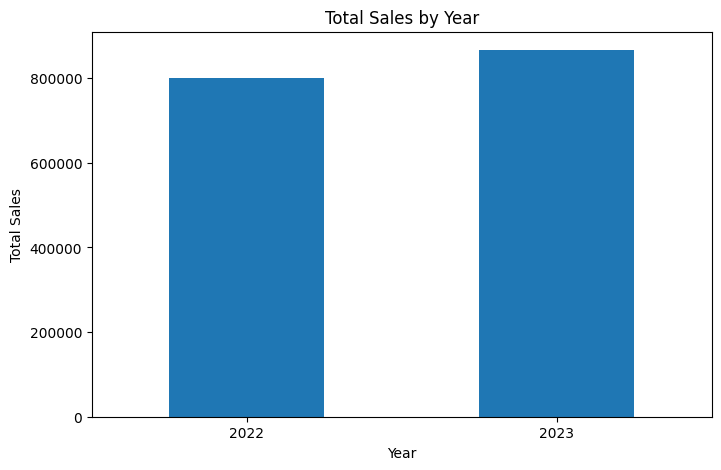

In [68]:
plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='bar')

plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Q1.How have sales changed over the years?

Sales increased steadily from 140.4M (2013) to 288.7M (2016). 2017 has 194.2M, but it only includes data until August.

Total sales by product family

MOnthly Sales Trend

In [70]:
monthly_sales = (
    train.groupby(train['date'].dt.to_period('M'))['sales']
    .sum()
)

monthly_sales.head()

,sales
date,
2022-01,64933.35
2022-02,59285.49
2022-03,67406.14
2022-04,64375.23
2022-05,67066.32


Visualize

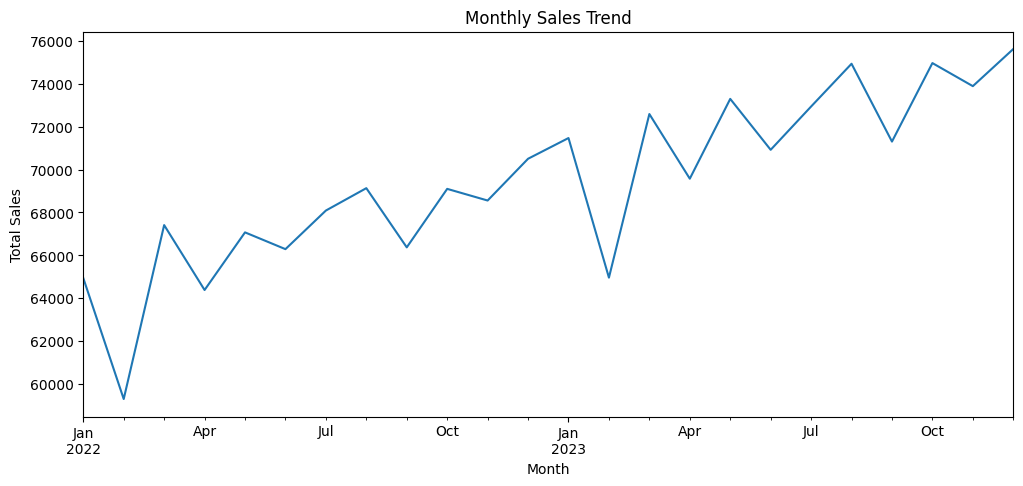

In [71]:
plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

###Q2. How do sales change month by month?
 We will write this answer based on the monthly graph/output you generated.

Which store has the highest Sales

In [73]:
store_sales = (
    train.groupby('store')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(store_sales.head(10))

store
9     178600.69
4     173784.73
6     172590.88
7     169942.26
1     169912.36
8     163896.68
5     161479.82
3     159553.75
2     159293.35
10    158517.85
Name: sales, dtype: float64


Visualize

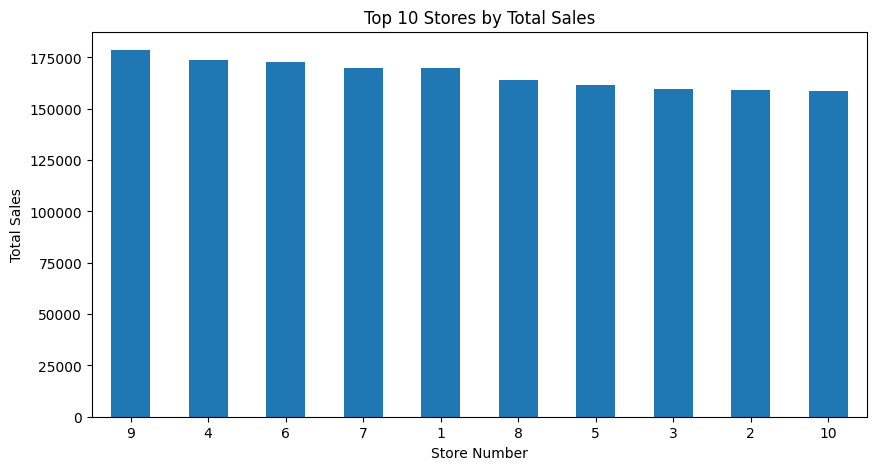

In [74]:
plt.figure(figsize=(10, 5))

store_sales.head(10).plot(kind='bar')

plt.title('Top 10 Stores by Total Sales')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

###Q3. Which stores have the highest sales?

 We will write this answer based on your top-store output.

Does Promotion affect sales

In [75]:
promotion_sales = (
    train.groupby(train['promo'] > 0)['sales']
    .mean()
)

print(promotion_sales)

promo
False    222.469076
True     251.973218
Name: sales, dtype: float64


In [76]:
print("Average sales without promotion:",
      promotion_sales[False])

print("Average sales with promotion:",
      promotion_sales[True])

Average sales without promotion: 222.46907623626373
Average sales with promotion: 251.97321815718155


###Q4. Does promotion affect sales?

 We will write this after seeing your promotion results.

Average sales by day of the week

In [82]:
day_sales = (
    train.groupby(train['date'].dt.day_name())['sales']
    .mean()
)

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

day_sales = day_sales.reindex(day_order)

print(day_sales)

date
Monday       227.806413
Tuesday      244.555788
Wednesday    248.047038
Thursday     237.186394
Friday       219.208702
Saturday     209.462419
Sunday       213.105067
Name: sales, dtype: float64


Visualization

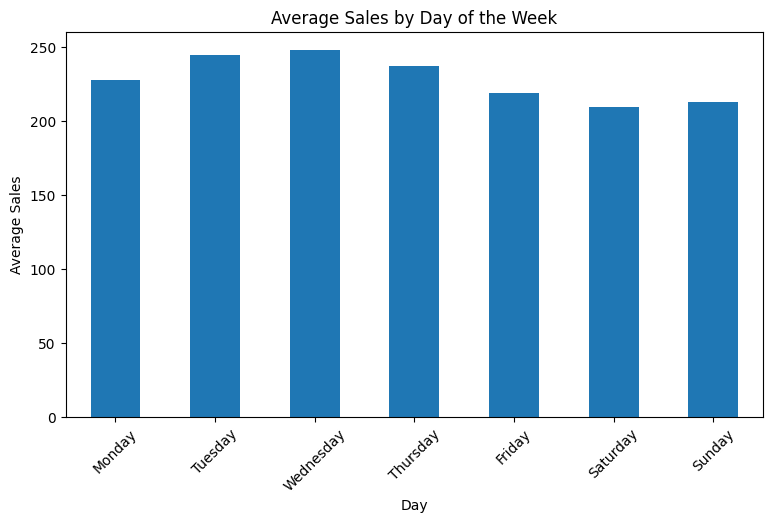

In [83]:
plt.figure(figsize=(9, 5))

day_sales.plot(kind='bar')

plt.title('Average Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)

plt.show()

###Q5: What is the average sales by day of the week?





Sales higher on weekends

In [84]:
weekend_sales = (
    clean_train.groupby('is_weekend')['sales']
    .mean()
)

print(weekend_sales)

is_weekend
0    235.360867
1    211.283743
Name: sales, dtype: float64


Visualize

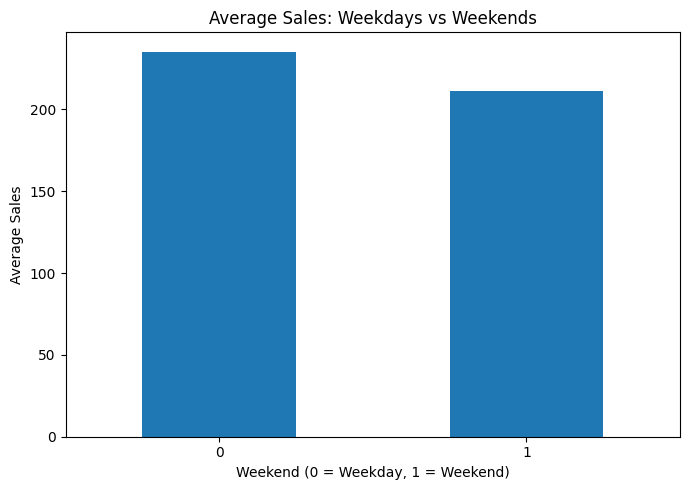

In [93]:
plt.figure(figsize=(7, 5))

weekend_sales.plot(kind='bar')

plt.title('Average Sales: Weekdays vs Weekends')
plt.xlabel('Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Q6. Are sales higher on weekends

Holiday affect sales?

In [86]:
holiday_sales = (
    clean_train.groupby('holiday')['sales']
    .mean()
)

print(holiday_sales)

holiday
0    224.357538
1    263.518513
Name: sales, dtype: float64


*Visualization*

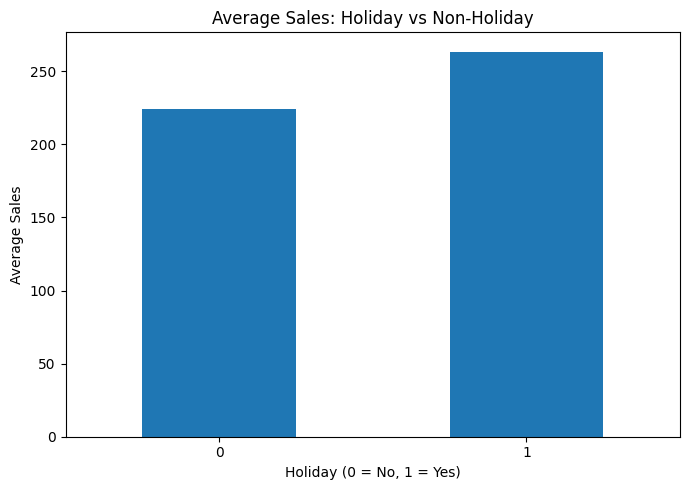

In [92]:
plt.figure(figsize=(7, 5))

holiday_sales.plot(kind='bar')

plt.title('Average Sales: Holiday vs Non-Holiday')
plt.xlabel('Holiday (0 = No, 1 = Yes)')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Q7. Does having a holiday affect sales?

Promotions affect on sales over time

In [87]:
promo_monthly = (
    clean_train
    .groupby([
        clean_train['date'].dt.to_period('M'),
        clean_train['promo']
    ])['sales']
    .mean()
)

print(promo_monthly.head(20))

date     promo
2022-01  0        204.147578
         1        234.658704
2022-02  0        206.083274
         1        233.840702
2022-03  0        209.416043
         1        240.505625
2022-04  0        208.994752
         1        237.905172
2022-05  0        210.068074
         1        239.541061
2022-06  0        213.434612
         1        246.564265
2022-07  0        213.556790
         1        241.661642
2022-08  0        216.655083
         1        245.585441
2022-09  0        214.579339
         1        248.944138
2022-10  0        217.891186
         1        245.106140
Name: sales, dtype: float64


Visualization

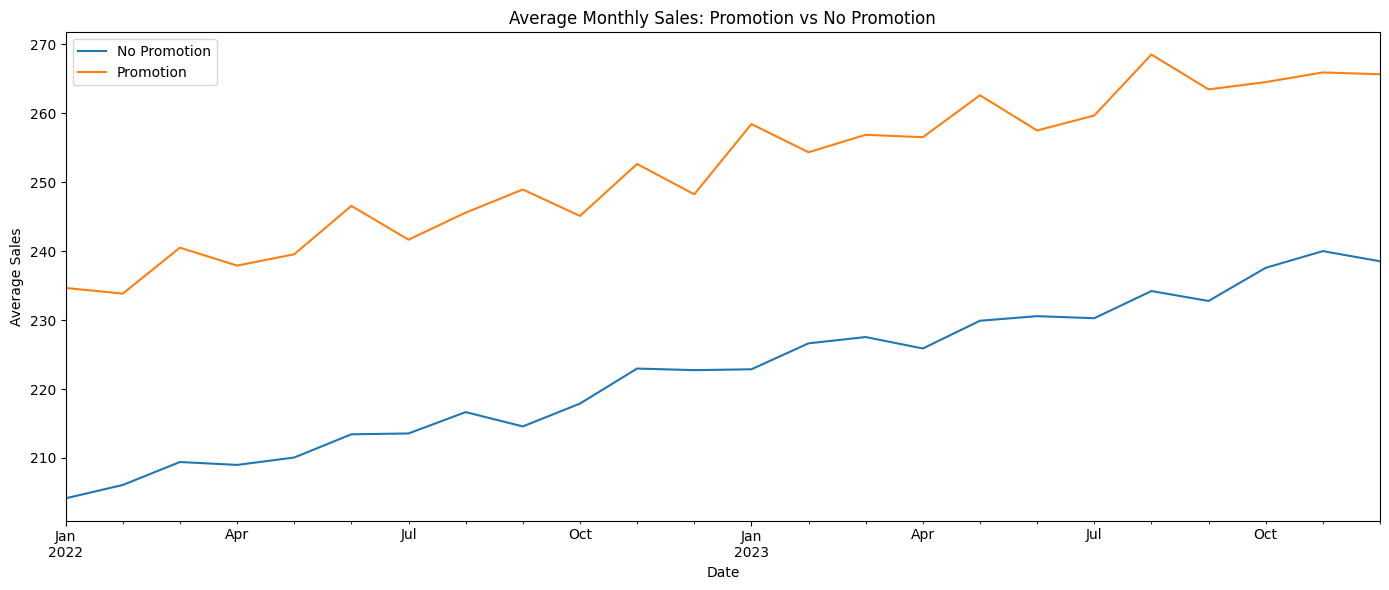

In [94]:
promo_monthly = (
    clean_train
    .groupby([
        clean_train['date'].dt.to_period('M'),
        clean_train['promo']
    ])['sales']
    .mean()
    .unstack()
)

promo_monthly.index = promo_monthly.index.to_timestamp()

plt.figure(figsize=(14, 6))

promo_monthly.plot(ax=plt.gca())

plt.title('Average Monthly Sales: Promotion vs No Promotion')
plt.xlabel('Date')
plt.ylabel('Average Sales')
plt.legend(['No Promotion', 'Promotion'])

plt.tight_layout()
plt.show()

Q8. How do promotions affect sales over time?

Store with highest average sales

In [88]:
store_avg_sales = (
    clean_train.groupby('store')['sales']
    .mean()
    .sort_values(ascending=False)
)

print(store_avg_sales)

store
9     244.658479
4     238.061274
6     236.425863
7     232.797616
1     232.756658
8     224.516000
5     221.205233
3     218.566781
2     218.210068
10    217.147740
Name: sales, dtype: float64


Visualiztaion

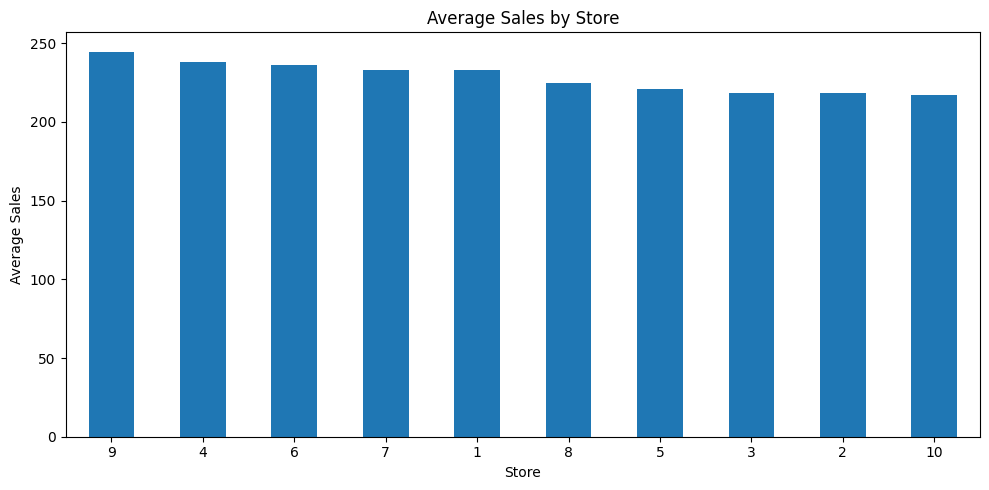

In [95]:
plt.figure(figsize=(10, 5))

store_avg_sales.plot(kind='bar')

plt.title('Average Sales by Store')
plt.xlabel('Store')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Q9. Which store has the highest average sales?

Relationship between sales, promotion & holidays

In [89]:
print(
    clean_train[['sales', 'promo', 'holiday']]
    .corr()
)

            sales     promo   holiday
sales    1.000000  0.445086  0.449217
promo    0.445086  1.000000 -0.002977
holiday  0.449217 -0.002977  1.000000


Visualize

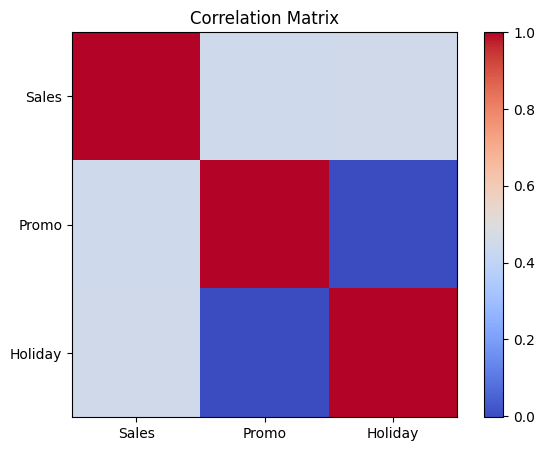

In [90]:
plt.figure(figsize=(7, 5))

plt.imshow(
    clean_train[['sales', 'promo', 'holiday']].corr(),
    cmap='coolwarm',
    interpolation='none'
)

plt.colorbar()

plt.xticks(
    range(3),
    ['Sales', 'Promo', 'Holiday']
)

plt.yticks(
    range(3),
    ['Sales', 'Promo', 'Holiday']
)

plt.title('Correlation Matrix')

plt.show()

Q10. What is the relationship between sales, promotion and holidays?

##Feature Engineering

Create date-based feature

In [96]:
# Make a copy of the cleaned dataset
df = clean_train.copy()

# Date-based features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Display the new features
display(df.head())

,date,store,sales,promo,holiday,year,month,day,day_of_week,is_weekend,quarter
0,2022-01-01,1,184.78,0,0,2022,1,1,5,1,1
1,2022-01-02,1,192.62,0,0,2022,1,2,6,1,1
2,2022-01-03,1,212.68,0,0,2022,1,3,0,0,1
3,2022-01-04,1,249.58,1,0,2022,1,4,1,0,1
4,2022-01-05,1,223.50,0,0,2022,1,5,2,0,1


Adding a  new `season` feature

In [97]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

display(df[['date', 'year', 'month', 'quarter',
            'day_of_week', 'is_weekend', 'season']].head())

,date,year,month,quarter,day_of_week,is_weekend,season
0,2022-01-01,2022,1,1,5,1,Winter
1,2022-01-02,2022,1,1,6,1,Winter
2,2022-01-03,2022,1,1,0,0,Winter
3,2022-01-04,2022,1,1,1,0,Winter
4,2022-01-05,2022,1,1,2,0,Winter


**Creating lag features**(tells the model what sales were like in previous days)

In [98]:
# Sort data correctly first
df = df.sort_values(['store', 'date'])

# Previous day sales
df['lag_1'] = df.groupby('store')['sales'].shift(1)

# Sales from 7 days ago
df['lag_7'] = df.groupby('store')['sales'].shift(7)

# Sales from 30 days ago
df['lag_30'] = df.groupby('store')['sales'].shift(30)

display(df[['date', 'store', 'sales', 'lag_1', 'lag_7', 'lag_30']].head(35))

,date,store,sales,lag_1,lag_7,lag_30
0,2022-01-01,1,184.78,NaN,NaN,NaN
1,2022-01-02,1,192.62,184.78,NaN,NaN
2,2022-01-03,1,212.68,192.62,NaN,NaN
3,2022-01-04,1,249.58,212.68,NaN,NaN
4,2022-01-05,1,223.50,249.58,NaN,NaN
5,2022-01-06,1,221.79,223.50,NaN,NaN
6,2022-01-07,1,200.43,221.79,NaN,NaN
7,2022-01-08,1,213.47,200.43,184.78,NaN
8,2022-01-09,1,222.44,213.47,192.62,NaN
9,2022-01-10,1,203.10,222.44,212.68,NaN


**Creating rolling average features**

In [99]:
# 7-day rolling average
df['rolling_mean_7'] = (
    df.groupby('store')['sales']
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

# 30-day rolling average
df['rolling_mean_30'] = (
    df.groupby('store')['sales']
      .transform(lambda x: x.shift(1).rolling(30).mean())
)

display(df[['date', 'store', 'sales',
            'rolling_mean_7', 'rolling_mean_30']].head(35))

,date,store,sales,rolling_mean_7,rolling_mean_30
0,2022-01-01,1,184.78,NaN,NaN
1,2022-01-02,1,192.62,NaN,NaN
2,2022-01-03,1,212.68,NaN,NaN
3,2022-01-04,1,249.58,NaN,NaN
4,2022-01-05,1,223.50,NaN,NaN
5,2022-01-06,1,221.79,NaN,NaN
6,2022-01-07,1,200.43,NaN,NaN
7,2022-01-08,1,213.47,212.197143,NaN
8,2022-01-09,1,222.44,216.295714,NaN
9,2022-01-10,1,203.10,220.555714,NaN


Checking the final features

In [100]:
print("Dataset shape:", df.shape)

print("\nFeatures:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (7300, 17)

Features:
['date', 'store', 'sales', 'promo', 'holiday', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'season', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30']

Missing values:
date                 0
store                0
sales                0
promo                0
holiday              0
year                 0
month                0
day                  0
day_of_week          0
is_weekend           0
quarter              0
season               0
lag_1               10
lag_7               70
lag_30             300
rolling_mean_7      70
rolling_mean_30    300
dtype: int64


Handle Missing Values

In [101]:
# Remove rows with missing values created by lag and rolling features
df = df.dropna().reset_index(drop=True)

print("Dataset shape after removing missing values:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape after removing missing values: (7000, 17)

Missing values:
date               0
store              0
sales              0
promo              0
holiday            0
year               0
month              0
day                0
day_of_week        0
is_weekend         0
quarter            0
season             0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64


In [102]:
display(df.head())

print("\nFinal Features:")
print(df.columns.tolist())

,date,store,sales,promo,holiday,year,month,day,day_of_week,is_weekend,quarter,season,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2022-01-31,1,255.73,0,1,2022,1,31,0,0,1,Winter,187.77,203.40,184.78,210.051429,211.397667
1,2022-02-01,1,252.09,1,0,2022,2,1,1,0,1,Winter,255.73,222.36,192.62,217.527143,213.762667
2,2022-02-02,1,220.78,0,0,2022,2,2,2,0,1,Winter,252.09,219.96,212.68,221.774286,215.745000
3,2022-02-03,1,219.41,0,0,2022,2,3,3,0,1,Winter,220.78,216.82,249.58,221.891429,216.015000
4,2022-02-04,1,191.89,0,0,2022,2,4,4,0,1,Winter,219.41,194.64,223.50,222.261429,215.009333



Final Features:
['date', 'store', 'sales', 'promo', 'holiday', 'year', 'month', 'day', 'day_of_week', 'is_weekend', 'quarter', 'season', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30']


Check the date range

In [103]:
print("Start date:", df['date'].min())
print("End date:", df['date'].max())
print("Total rows:", len(df))

Start date: 2022-01-31 00:00:00
End date: 2023-12-31 00:00:00
Total rows: 7000


Splitting Dataset

In [104]:
# Make sure data is sorted by date
df = df.sort_values('date').reset_index(drop=True)

# Find split points
train_end = int(len(df) * 0.70)
validation_end = int(len(df) * 0.85)

# Chronological split
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

print("Training set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

Training set: (4900, 17)
Validation set: (1050, 17)
Test set: (1050, 17)


Verify that there is no date overlap

In [105]:
print("Training:", train_df['date'].min(), "to", train_df['date'].max())
print("Validation:", val_df['date'].min(), "to", val_df['date'].max())
print("Test:", test_df['date'].min(), "to", test_df['date'].max())

Training: 2022-01-31 00:00:00 to 2023-06-04 00:00:00
Validation: 2023-06-05 00:00:00 to 2023-09-17 00:00:00
Test: 2023-09-18 00:00:00 to 2023-12-31 00:00:00


Separate X and y

In [106]:
# Features to use for prediction
features = [
    'store',
    'promo',
    'holiday',
    'year',
    'month',
    'day',
    'day_of_week',
    'is_weekend',
    'quarter',
    'season',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30'
]

# Separate features (X) and target (y)
X_train = train_df[features]
y_train = train_df['sales']

X_val = val_df[features]
y_val = val_df['sales']

X_test = test_df[features]
y_test = test_df['sales']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4900, 15)
y_train: (4900,)
X_val: (1050, 15)
y_val: (1050,)
X_test: (1050, 15)
y_test: (1050,)


Encode season

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical and numerical features
categorical_features = ['season']

numerical_features = [
    'store',
    'promo',
    'holiday',
    'year',
    'month',
    'day',
    'day_of_week',
    'is_weekend',
    'quarter',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30'
]

# Create preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('season', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Fit only on training data
X_train_encoded = preprocessor.fit_transform(X_train)

# Transform validation and test using the same fitted transformer
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

print("X_train after encoding:", X_train_encoded.shape)
print("X_val after encoding:", X_val_encoded.shape)
print("X_test after encoding:", X_test_encoded.shape)

X_train after encoding: (4900, 18)
X_val after encoding: (1050, 18)
X_test after encoding: (1050, 18)


###**Model1:Linear Regression**

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_encoded, y_train)

# Predict validation data
lr_val_pred = lr_model.predict(X_val_encoded)

# Evaluate validation performance
lr_mae = mean_absolute_error(y_val, lr_val_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_r2 = r2_score(y_val, lr_val_pred)

print("Linear Regression - Validation Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression - Validation Results
MAE : 7.2525717103450855
RMSE: 8.949121538116906
R²  : 0.8671200416132446


###**Model 2: Random Forest**

In [109]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_encoded, y_train)

# Predict validation data
rf_val_pred = rf_model.predict(X_val_encoded)

# Evaluate validation performance
rf_mae = mean_absolute_error(y_val, rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_r2 = r2_score(y_val, rf_val_pred)

print("Random Forest - Validation Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest - Validation Results
MAE : 5.5352274285714245
RMSE: 6.96508100287221
R²  : 0.9195083159115574


Final Test Evaluation — Random Forest

In [110]:
# Predict on the final unseen test set
rf_test_pred = rf_model.predict(X_test_encoded)

# Final test metrics
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest - Final Test Results")
print("MAE :", rf_test_mae)
print("RMSE:", rf_test_rmse)
print("R²  :", rf_test_r2)

Random Forest - Final Test Results
MAE : 6.62619419047619
RMSE: 8.374122168637543
R²  : 0.8769587276978462


Comparison Both Models

In [111]:
# Model comparison
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})

display(comparison)

,Model,MAE,RMSE,R2
0,Linear Regression,7.252572,8.949122,0.867120
1,Random Forest,5.535227,6.965081,0.919508


Actual vs Predicted Sales

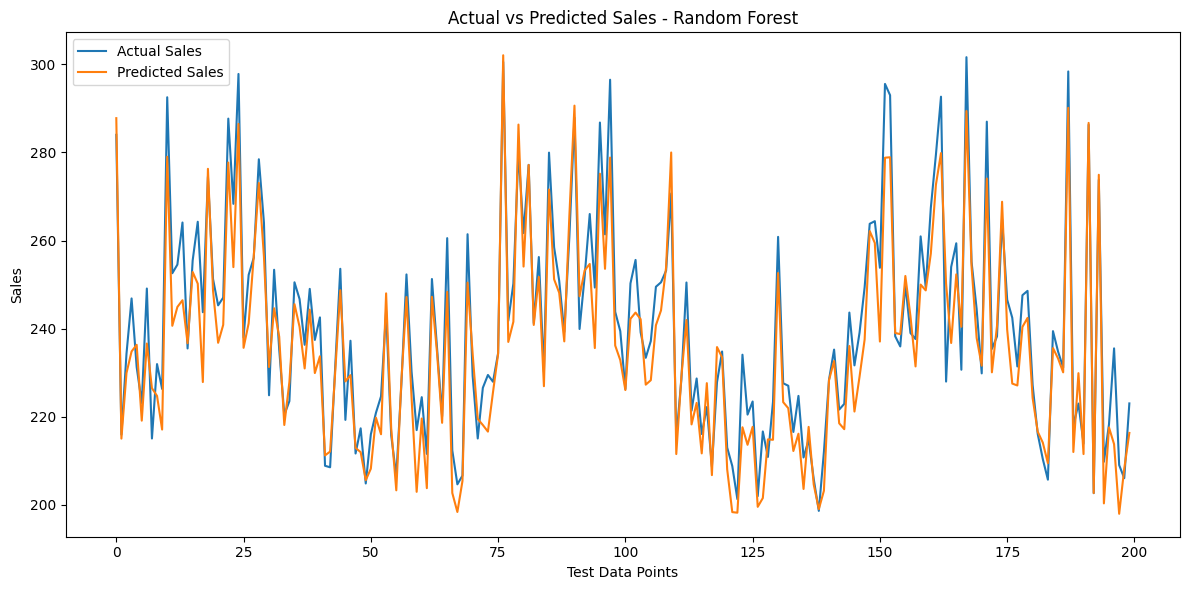

In [112]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values[:200],
    label='Actual Sales'
)

plt.plot(
    rf_test_pred[:200],
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales - Random Forest')
plt.xlabel('Test Data Points')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

Feature Importance

In [113]:
# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()

# Feature importance
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

display(importance)

,Feature,Importance
10,remainder__day_of_week,0.274688
6,remainder__holiday,0.232640
5,remainder__promo,0.222473
17,remainder__rolling_mean_30,0.202951
14,remainder__lag_7,0.022309
15,remainder__lag_30,0.008455
13,remainder__lag_1,0.008108
16,remainder__rolling_mean_7,0.007559
9,remainder__day,0.005302
8,remainder__month,0.003924


Visualization of Top Features

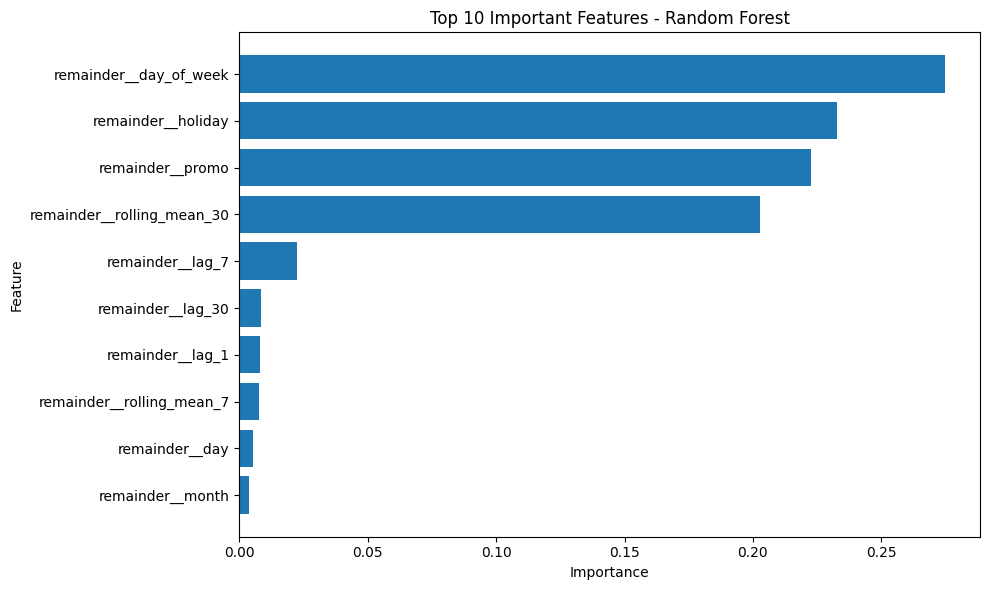

In [114]:
plt.figure(figsize=(10, 6))

top_features = importance.head(10).sort_values('Importance')

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Important Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

Saving the Trained Models

In [115]:
import os
import joblib

# Folder in Google Drive
model_path = '/content/drive/MyDrive/'

# Create folder
os.makedirs(model_path, exist_ok=True)

# Save trained models
joblib.dump(lr_model, f'{model_path}/linear_regression.pkl')
joblib.dump(rf_model, f'{model_path}/random_forest.pkl')

# Save preprocessing object
joblib.dump(preprocessor, f'{model_path}/preprocessor.pkl')

print("Models saved to Google Drive successfully!")
print(model_path)

Models saved to Google Drive successfully!
/content/drive/MyDrive/


Saving the Forecast Results

In [118]:
forecast_results = test_df[['date', 'store', 'sales']].copy()

forecast_results['predicted_sales'] = rf_test_pred

forecast_results.to_csv(
    'forecast_results.csv',
    index=False
)

display(forecast_results.head())

,date,store,sales,predicted_sales
5950,2023-09-18,9,284.01,287.7924
5951,2023-09-18,10,215.94,215.0271
5952,2023-09-18,7,234.30,229.9225
5953,2023-09-18,4,246.86,234.8282
5954,2023-09-18,1,231.27,236.3302


In [119]:
import os

save_path = '/content/drive/MyDrive/'
os.makedirs(save_path, exist_ok=True)

clean_train.to_csv(
    f'{save_path}/forecast_results.csv',
    index=False
)

print("Clean dataset saved successfully!")
print(f"Location: {save_path}/forecast_results.csv")

Clean dataset saved successfully!
Location: /content/drive/MyDrive//forecast_results.csv


Forecast Summary

In [120]:
print("Average actual sales:",
      round(y_test.mean(), 2))

print("Average predicted sales:",
      round(rf_test_pred.mean(), 2))

print("Total actual sales:",
      round(y_test.sum(), 2))

print("Total predicted sales:",
      round(rf_test_pred.sum(), 2))

Average actual sales: 243.54
Average predicted sales: 239.66
Total actual sales: 255717.3
Total predicted sales: 251638.04


Final Forecast Visualization

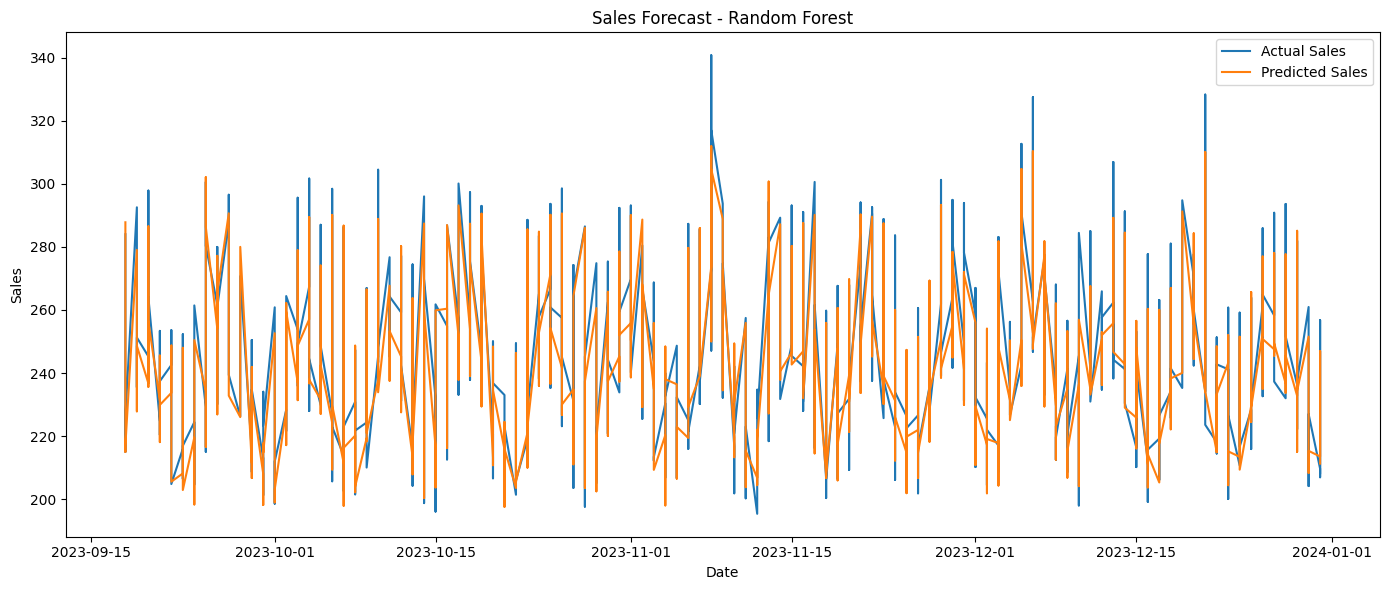

In [122]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df['date'],
    y_test,
    label='Actual Sales'
)

plt.plot(
    test_df['date'],
    rf_test_pred,
    label='Predicted Sales'
)

plt.title('Sales Forecast - Random Forest')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()